# Import Necessery Libraries

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

# Import Dataframe

In [106]:
df = pd.read_csv("car_price_prediction_dataset.csv")
df.head()

,Car_ID,Brand,Year,Mileage(km),Engine_Size(L),Fuel_Type,Transmission,Doors,Color,Condition,Accidents_Reported,Price(USD)
0,CAR0001,Honda,2020,102548,3.5,Petrol,Automatic,4,Blue,Poor,2,16790
1,CAR0002,Chevrolet,2021,150799,1.0,Hybrid,Manual,2,Grey,Excellent,2,20229
2,CAR0003,Volkswagen,2012,34579,1.0,Electric,Manual,4,Blue,Fair,2,17817
3,CAR0004,BMW,2015,96554,1.6,Petrol,Automatic,4,Silver,Excellent,1,47012
4,CAR0005,Ford,2006,147627,1.4,Petrol,Automatic,4,Silver,Excellent,0,10440


# Quick Look of the Dataframe

In [107]:
print("Shape:", df.shape)
print("\nMissing values:", df.isna().sum().sum())
print("\nPrice stats:\n", df['Price(USD)'].describe().round(0))

Shape: (1000, 12)

Missing values: 0

Price stats:
 count     1000.0
mean     24584.0
std      11142.0
min       4462.0
25%      16665.0
50%      22524.0
75%      30512.0
max      62983.0
Name: Price(USD), dtype: float64


# Basic feature selection & target

In [108]:
target = 'Price(USD)'

features = [
    'Brand', 'Year', 'Mileage(km)', 'Engine_Size(L)',
    'Fuel_Type', 'Transmission', 'Doors', 'Condition',
    'Accidents_Reported'
    # 'Color' → usually weak predictor, omitted for simplicity
]

X = df[features].copy()
y = df[target].copy()

print("Features used:", features)

Features used: ['Brand', 'Year', 'Mileage(km)', 'Engine_Size(L)', 'Fuel_Type', 'Transmission', 'Doors', 'Condition', 'Accidents_Reported']


# Define categorical & numerical columns

In [109]:
categorical_cols = ['Brand', 'Fuel_Type', 'Transmission', 'Condition']
numerical_cols   = ['Year', 'Mileage(km)', 'Engine_Size(L)', 'Doors', 'Accidents_Reported']

print("Categorical:", categorical_cols)
print("Numerical:  ", numerical_cols)

Categorical: ['Brand', 'Fuel_Type', 'Transmission', 'Condition']
Numerical:   ['Year', 'Mileage(km)', 'Engine_Size(L)', 'Doors', 'Accidents_Reported']


# Create preprocessing + model pipeline

In [110]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

# Train / test split

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print(f"Train: {X_train.shape[0]} rows")
print(f" Test: {X_test.shape[0]} rows")

Train: 750 rows
 Test: 250 rows


# Train the model

In [112]:
model.fit(X_train, y_train)
print("Model fitted ✓")

Model fitted ✓


# Evaluate The Model

In [113]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Linear Regression – Car Price Prediction")
print("────────────────────────────────────────")
print(f"MAE:  {mae:,.0f} USD")
print(f"RMSE: {rmse:,.0f} USD")
print(f"R²:   {r2:.3f}  ({r2*100:.1f}%)")

Linear Regression – Car Price Prediction
────────────────────────────────────────
MAE:  2,447 USD
RMSE: 3,144 USD
R²:   0.925  (92.5%)


# Feature coefficients (feature importance)

In [114]:
# Get feature names after encoding
num_features = numerical_cols
cat_features = list(model.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .get_feature_names_out(categorical_cols))

all_features = num_features + cat_features

coefs = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefs.round(2)
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df.style.format({'Coefficient': '{:.2f}'})

,Feature,Coefficient
6,Brand_Chevrolet,-15820.46
9,Brand_Hyundai,-15655.24
7,Brand_Ford,-14596.20
11,Brand_Nissan,-13934.13
20,Condition_Poor,-13612.91
8,Brand_Honda,-12611.58
12,Brand_Toyota,-11595.85
18,Condition_Fair,-9403.00
13,Brand_Volkswagen,-9080.05
0,Year,5254.23


# Actual vs Predicted plot

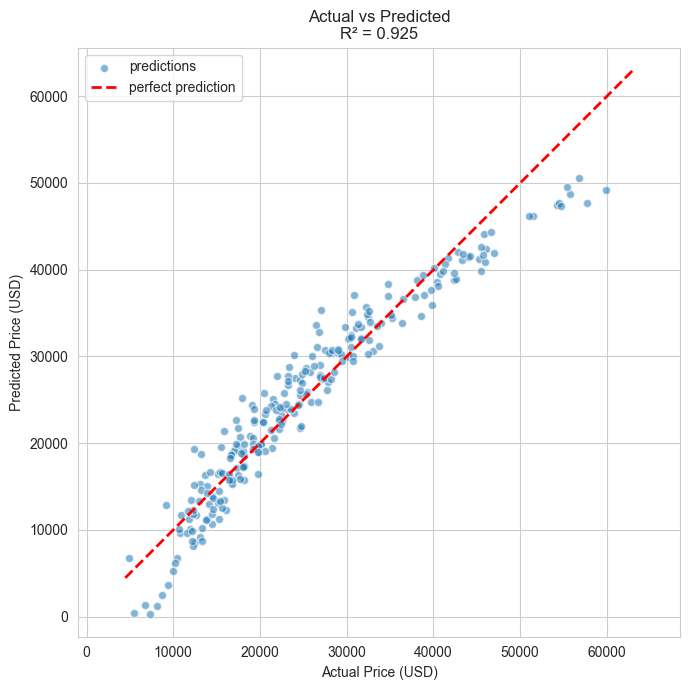

In [115]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.55, s=35, edgecolor='white', label='predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='perfect prediction')

plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title(f'Actual vs Predicted\nR² = {r2:.3f}')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

# Example prediction (new car)

In [116]:
new_car = pd.DataFrame({
    'Brand':              ['Toyota'],
    'Year':               [2021],
    'Mileage(km)':        [45000],
    'Engine_Size(L)':     [2.0],
    'Fuel_Type':          ['Petrol'],
    'Transmission':       ['Automatic'],
    'Doors':              [4],
    'Condition':          ['Excellent'],
    'Accidents_Reported': [0]
})

predicted_price = model.predict(new_car)[0]

print(f"Estimated price: ${predicted_price:,.0f}")

Estimated price: $37,091
